<a href="https://colab.research.google.com/github/bharath-hue/TASK_TNS_AIML/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Forward Propagation

Input:
[[0.5]
 [0.8]
 [0.2]]

Hidden Layer Activations:
[[0.63181242]
 [0.70889017]]

Output:
[[0.78869692]]


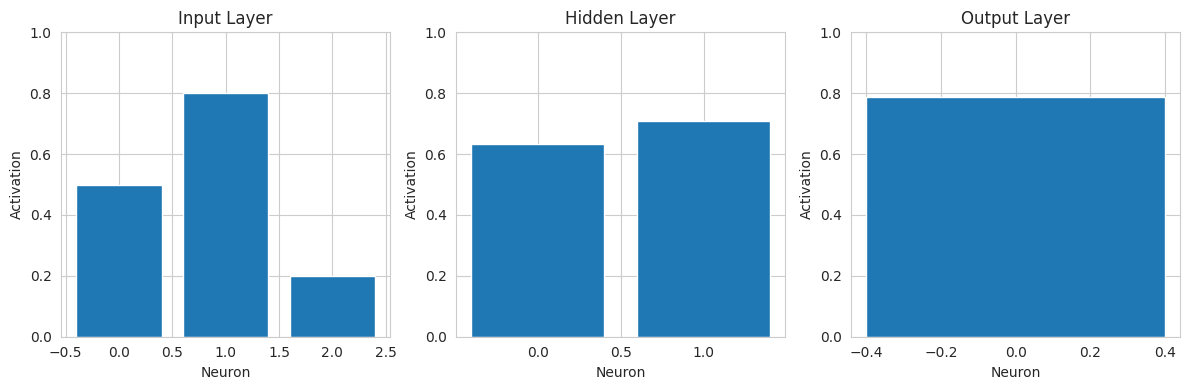

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Activation Function
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# -----------------------------
# Input Layer (3 neurons)
# -----------------------------
X = np.array([[0.5],
              [0.8],
              [0.2]])

# -----------------------------
# Hidden Layer Weights & Biases
# -----------------------------
W1 = np.array([[0.2, 0.4, 0.1],
               [0.7, 0.3, 0.5]])

b1 = np.array([[0.1],
               [0.2]])

# -----------------------------
# Output Layer Weights & Biases
# -----------------------------
W2 = np.array([[0.6, 0.9]])
b2 = np.array([[0.3]])

# -----------------------------
# Forward Propagation
# -----------------------------

# Hidden Layer
Z1 = np.dot(W1, X) + b1
A1 = sigmoid(Z1)

# Output Layer
Z2 = np.dot(W2, A1) + b2
A2 = sigmoid(Z2)

print("Input:")
print(X)

print("\nHidden Layer Activations:")
print(A1)

print("\nOutput:")
print(A2)

# -----------------------------
# Visualization
# -----------------------------
layers = {
    "Input": X.flatten(),
    "Hidden": A1.flatten(),
    "Output": A2.flatten()
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (layer_name, values) in zip(axes, layers.items()):
    ax.bar(range(len(values)), values)
    ax.set_title(layer_name + " Layer")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Neuron")
    ax.set_ylabel("Activation")

plt.tight_layout()
plt.show()

#2. Loss Functions

#a. Mean Squared Error (MSE)

In [ ]:
from sklearn.metrics import mean_squared_error

actual = [10,20,30]

predicted = [12,18,35]

loss = mean_squared_error(actual,predicted)

print(loss)

11.0


#b. Binary Cross Entropy

In [ ]:
from sklearn.metrics import log_loss

actual = [1,0,1]

prediction = [0.9,0.2,0.8]

print(log_loss(actual,prediction))

0.18388253942874858


# c. Categorical Cross Entropy

In [ ]:
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

# One-hot encoded true labels
y_true = tf.constant([
    [0, 1, 0],
    [1, 0, 0],
    [0, 0, 1]
], dtype=tf.float32)

# Predicted probabilities (from Softmax layer)
y_pred = tf.constant([
    [0.1, 0.7, 0.2],
    [0.8, 0.1, 0.1],
    [0.2, 0.2, 0.6]
], dtype=tf.float32)

# Create loss object
cce = CategoricalCrossentropy()

# Compute loss
loss = cce(y_true, y_pred)

print("Categorical Cross Entropy Loss:", loss.numpy())

Categorical Cross Entropy Loss: 0.36354804


#3. Backward Propagation


In [ ]:
# Initial values
weight = 2.5
gradient = 0.8
learning_rate = 0.1

# Weight update
new_weight = weight - learning_rate * gradient

print("Old Weight:", weight)
print("Gradient:", gradient)
print("New Weight:", new_weight)

Old Weight: 2.5
Gradient: 0.8
New Weight: 2.42


#4. Gradient Descent


In [ ]:
# Initial values
weight = 5
gradient = 3
learning_rate = 0.1

for epoch in range(5):
    weight = weight - learning_rate * gradient
    print(f"Epoch {epoch+1}: Weight = {weight:.2f}")

Epoch 1: Weight = 4.70
Epoch 2: Weight = 4.40
Epoch 3: Weight = 4.10
Epoch 4: Weight = 3.80
Epoch 5: Weight = 3.50


#Building Neural Networks with TensorFlow/Keras


In [ ]:
# ==========================================
# Building a Neural Network using TensorFlow/Keras
# Example: Predict Pass/Fail based on Study Hours
# ==========================================

# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# ------------------------------------------
# Step 2: Create Dataset
# ------------------------------------------

# Input (Study Hours)
X = np.array([
    [2],
    [4],
    [6],
    [8],
    [10]
])

# Output (0 = Fail, 1 = Pass)
y = np.array([
    0,
    0,
    1,
    1,
    1
])

# ------------------------------------------
# Step 3: Build Neural Network
# ------------------------------------------

model = Sequential([
    Dense(8, activation='relu', input_shape=(1,)),   # Hidden Layer 1
    Dense(4, activation='relu'),                     # Hidden Layer 2
    Dense(1, activation='sigmoid')                   # Output Layer
])

# ------------------------------------------
# Step 4: Compile the Model
# ------------------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------
# Step 5: Train the Model
# ------------------------------------------

print("Training Started...\n")

history = model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("\nTraining Completed!")

# ------------------------------------------
# Step 6: Evaluate the Model
# ------------------------------------------

loss, accuracy = model.evaluate(X, y, verbose=0)

print("\nModel Evaluation")
print("-----------------------")
print("Loss     :", round(loss, 4))
print("Accuracy :", round(accuracy * 100, 2), "%")

# ------------------------------------------
# Step 7: Make Predictions
# ------------------------------------------

print("\nPredictions")
print("-----------------------")

test_data = np.array([
    [3],
    [5],
    [7],
    [9]
])

predictions = model.predict(test_data)

for hours, pred in zip(test_data, predictions):
    probability = pred[0]

    if probability >= 0.5:
        result = "Pass"
    else:
        result = "Fail"

    print(f"Study Hours: {hours[0]} -> Probability: {probability:.4f} -> Prediction: {result}")

# ------------------------------------------
# Step 8: Model Summary
# ------------------------------------------

print("\nModel Summary")
print("-----------------------")
model.summary()

# ------------------------------------------
# Step 9: Display Weights and Biases
# ------------------------------------------

print("\nModel Weights and Biases")
print("-----------------------")

for i, layer in enumerate(model.layers):
    weights, biases = layer.get_weights()

    print(f"\nLayer {i+1}")
    print("Weights:")
    print(weights)

    print("Biases:")
    print(biases)

# ------------------------------------------
# Step 10: Predict for a New Student
# ------------------------------------------

study_hours = 3

prediction = model.predict(np.array([[study_hours]]))

print("\nNew Student Prediction")
print("-----------------------")
print("Study Hours :", study_hours)
print("Probability :", prediction[0][0])

if prediction[0][0] >= 0.5:
    print("Final Prediction : PASS")
else:
    print("Final Prediction : FAIL")

Training Started...

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6000 - loss: 0.5966
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6000 - loss: 0.5942
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6000 - loss: 0.5918
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6000 - loss: 0.5895
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6000 - loss: 0.5872
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6000 - loss: 0.5850
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6000 - loss: 0.5827
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6000 - loss: 0.5806
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6000 - loss: 0.5784
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6000 - loss: 0.5763
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6000 - loss: 0.5742
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6000 - loss: 0.5722
Epo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173 (696.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 116 (468.00 B)


Model Weights and Biases
-----------------------

Layer 1
Weights:
[[-0.41682792 -0.18446952  0.75219685 -0.71688306  0.5556264  -0.7418342
  -0.46700767 -0.09451151]]
Biases:
[ 0.          0.         -0.12612666  0.          0.12346017  0.
  0.          0.        ]

Layer 2
Weights:
[[-0.59473246 -0.21480393 -0.52441585  0.3810987 ]
 [-0.3604515   0.4691556  -0.11242032 -0.32495034]
 [ 0.427979   -0.49082592 -0.3616879   0.6202331 ]
 [ 0.46976405 -0.51768214  0.4645936   0.5184484 ]
 [-0.18752696  0.6165003   0.30857986 -0.03750528]
 [-0.6957492   0.5580042   0.33102065 -0.681601  ]
 [ 0.704433   -0.25830573  0.40829712  0.43998355]
 [-0.5377373   0.31110758  0.64071566  0.3578493 ]]
Biases:
[-0.1256767   0.1248875   0.         -0.12419415]

Layer 3
Weights:
[[ 0.27370116]
 [-0.35734314]
 [ 0.76829517]
 [ 0.3535447 ]]
Biases:
[-0.12191837]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

New Student Prediction
-----------------------
Study Hours : 3
Probability : 0.5830964
Final Prediction : P